# 📊 Simple Imputation Complete Guide
## Mean, Median, Arbitrary & End Distribution Imputation Techniques

---

### 🎯 What You'll Learn:
- **Mean/Median Imputation** - Statistical central tendency filling
- **Arbitrary Value Imputation** - Custom value filling for flagging missing data
- **End Distribution Imputation** - Extreme value filling for tree-based models
- **Professional templates** - Production-ready imputation pipelines

---

## 1. 🤔 Understanding Simple Imputation

### 📊 **When to Use Each Method:**

| **Method** | **Best For** | **Data Distribution** | **Missing %** | **Algorithm Compatibility** |
|------------|--------------|----------------------|---------------|----------------------------|
| **Mean** | Normal distribution | Symmetric | < 5% | Linear models, Neural networks |
| **Median** | Skewed distribution | Any shape | < 5% | All algorithms |
| **Arbitrary** | Flag missingness | Any | Any % | Tree-based models |
| **End Distribution** | Extreme flagging | Numerical only | Any % | Tree-based models |

### ⚠️ **Key Rules:**
- **< 5% missing**: Use Mean/Median imputation
- **Random missingness**: Safe to use statistical imputation  
- **Informative missingness**: Use Arbitrary/End Distribution
- **Tree-based models**: Can handle any imputation method
- **Linear models**: Prefer Mean/Median imputation

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sklearn imports
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print("📊 Ready for Simple Imputation techniques!")

✅ Libraries imported successfully!
📊 Ready for Simple Imputation techniques!


In [2]:
# 2. 📊 Load and Prepare Data

# Load Titanic data with proper error handling
def load_titanic_data():
    """Load and prepare Titanic dataset for imputation analysis"""

    try:
        # Try to load from your path
        df = pd.read_csv(
            r'C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\train.csv')
        print("✅ Loaded Titanic data from local path!")
    except FileNotFoundError:
        # Create synthetic Titanic-like data if file not found
        print("📁 Local file not found, creating synthetic Titanic data...")
        np.random.seed(42)
        n_samples = 891

        df = pd.DataFrame({
            'Age': np.random.normal(30, 12, n_samples),
            'Fare': np.random.exponential(32, n_samples),
            'SibSp': np.random.poisson(0.5, n_samples),
            'Parch': np.random.poisson(0.4, n_samples),
            'Survived': np.random.choice([0, 1], n_samples, p=[0.62, 0.38])
        })

        # Add missing values like real Titanic data
        age_missing_idx = np.random.choice(
            df.index, size=177, replace=False)  # ~20% missing
        fare_missing_idx = np.random.choice(
            df.index, size=1, replace=False)   # 1 missing

        df.loc[age_missing_idx, 'Age'] = np.nan
        df.loc[fare_missing_idx, 'Fare'] = np.nan

        print("✅ Created synthetic Titanic data!")

    return df


# Load data
df = load_titanic_data()

print(f"📊 Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print(f"\nMissing values analysis:")
missing_analysis = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_analysis,
    'Missing_Percent': missing_percent
})
print(missing_summary)

📁 Local file not found, creating synthetic Titanic data...
✅ Created synthetic Titanic data!
📊 Dataset shape: (891, 5)

First 5 rows:
         Age       Fare  SibSp  Parch  Survived
0  35.960570  38.258549      0      0         0
1  28.340828  36.475977      2      0         0
2  37.772262  30.845965      1      0         1
3        NaN  44.711053      0      1         1
4        NaN   5.526214      0      0         0

Missing values analysis:
          Missing_Count  Missing_Percent
Age                 177        19.865320
Fare                  1         0.112233
SibSp                 0         0.000000
Parch                 0         0.000000
Survived              0         0.000000


In [3]:
# 3. 🔧 Data Preprocessing (Your Method Enhanced)

def create_family_feature(df):
    """
    Create family feature like your original code but enhanced
    """

    print("👨‍👩‍👧‍👦 CREATING FAMILY FEATURE")
    print("=" * 40)

    # Create family size (your approach enhanced)
    df_enhanced = df.copy()
    df_enhanced['Family'] = df_enhanced['SibSp'] + df_enhanced['Parch']

    # Additional family-based features
    df_enhanced['IsAlone'] = (df_enhanced['Family'] == 0).astype(int)
    df_enhanced['FamilySize_Category'] = pd.cut(
        df_enhanced['Family'],
        bins=[-1, 0, 2, 4, 10],
        labels=['Alone', 'Small', 'Medium', 'Large']
    )

    print(f"✅ Original SibSp + Parch → Family feature")
    print(f"✅ Added IsAlone indicator")
    print(f"✅ Added FamilySize_Category")

    # Your cleaning approach
    columns_to_drop = ['SibSp', 'Parch']
    df_clean = df_enhanced.drop(columns=columns_to_drop)

    print(f"\n📊 Shape after feature engineering: {df_clean.shape}")
    print(f"📊 Family feature distribution:")
    print(df_clean['Family'].value_counts().sort_index())

    return df_clean


# Create enhanced dataset
df_processed = create_family_feature(df)
print("\n📋 Processed dataset:")
print(df_processed.head())

# Check missing values in processed data
print(f"\n📊 Missing values in processed data:")
print((df_processed.isnull().sum() / len(df_processed)) * 100)

👨‍👩‍👧‍👦 CREATING FAMILY FEATURE
✅ Original SibSp + Parch → Family feature
✅ Added IsAlone indicator
✅ Added FamilySize_Category

📊 Shape after feature engineering: (891, 6)
📊 Family feature distribution:
Family
0    365
1    332
2    140
3     41
4     11
5      2
Name: count, dtype: int64

📋 Processed dataset:
         Age       Fare  Survived  Family  IsAlone FamilySize_Category
0  35.960570  38.258549         0       0        1               Alone
1  28.340828  36.475977         0       2        0               Small
2  37.772262  30.845965         1       1        0               Small
3        NaN  44.711053         1       1        0               Small
4        NaN   5.526214         0       0        1               Alone

📊 Missing values in processed data:
Age                    19.865320
Fare                    0.112233
Survived                0.000000
Family                  0.000000
IsAlone                 0.000000
FamilySize_Category     0.000000
dtype: float64


In [4]:
# 4. 📈 Method 1: Mean & Median Imputation

class StatisticalImputer:
    """
    Professional Statistical Imputation Class
    """

    def __init__(self):
        self.statistics_ = {}
        self.is_fitted = False

    def analyze_distribution(self, df, columns):
        """Analyze distribution to recommend mean vs median"""

        print("📊 DISTRIBUTION ANALYSIS FOR IMPUTATION STRATEGY")
        print("=" * 60)

        recommendations = {}

        for col in columns:
            if col not in df.columns:
                continue

            data = df[col].dropna()

            # Calculate statistics
            mean_val = data.mean()
            median_val = data.median()
            skewness = data.skew()

            # Shapiro-Wilk test for normality (if sample < 5000)
            if len(data) < 5000:
                shapiro_stat, shapiro_p = stats.shapiro(data[:5000])
                is_normal = shapiro_p > 0.05
            else:
                is_normal = abs(skewness) < 0.5

            # Recommendation logic
            if is_normal and abs(skewness) < 0.5:
                recommendation = "mean"
                reason = "Normal distribution (low skewness)"
            else:
                recommendation = "median"
                reason = f"Skewed distribution (skewness: {skewness:.2f})"

            recommendations[col] = {
                'mean': mean_val,
                'median': median_val,
                'skewness': skewness,
                'recommendation': recommendation,
                'reason': reason
            }

            print(f"\n{col}:")
            print(f"   Mean: {mean_val:.2f}")
            print(f"   Median: {median_val:.2f}")
            print(f"   Skewness: {skewness:.2f}")
            print(f"   📋 Recommendation: Use {recommendation} ({reason})")

        return recommendations

    def fit_transform(self, X_train, y_train=None):
        """Fit and transform training data"""

        # Analyze distributions
        numerical_cols = X_train.select_dtypes(include=[np.number]).columns
        missing_cols = [
            col for col in numerical_cols if X_train[col].isnull().any()]

        if not missing_cols:
            print("ℹ️ No missing values found in numerical columns")
            return X_train.copy()

        recommendations = self.analyze_distribution(X_train, missing_cols)

        # Apply imputation
        X_imputed = X_train.copy()

        print(f"\n🔧 APPLYING STATISTICAL IMPUTATION")
        print("=" * 50)

        for col in missing_cols:
            strategy = recommendations[col]['recommendation']

            if strategy == 'mean':
                impute_value = recommendations[col]['mean']
                X_imputed[f'{col}_mean'] = X_train[col].fillna(impute_value)
            else:
                impute_value = recommendations[col]['median']
                X_imputed[f'{col}_median'] = X_train[col].fillna(impute_value)

            # Store statistics for transform
            self.statistics_[col] = {
                'strategy': strategy,
                'value': impute_value
            }

            print(f"✅ {col}: Filled with {strategy} = {impute_value:.2f}")

        self.is_fitted = True
        return X_imputed

    def transform(self, X_test):
        """Transform test data using fitted statistics"""

        if not self.is_fitted:
            raise ValueError("Must call fit_transform first!")

        X_imputed = X_test.copy()

        for col, stats in self.statistics_.items():
            if col in X_test.columns:
                strategy = stats['strategy']
                value = stats['value']
                X_imputed[f'{col}_{strategy}'] = X_test[col].fillna(value)

        return X_imputed


# Prepare data for imputation
X = df_processed.drop(columns=['Survived'])
y = df_processed['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Training set: {X_train.shape}")
print(f"📊 Test set: {X_test.shape}")

# Apply statistical imputation
stat_imputer = StatisticalImputer()
X_train_imputed = stat_imputer.fit_transform(X_train)
X_test_imputed = stat_imputer.transform(X_test)

print(f"\n📋 Imputed training set columns:")
print(list(X_train_imputed.columns))

📊 Training set: (712, 5)
📊 Test set: (179, 5)
📊 DISTRIBUTION ANALYSIS FOR IMPUTATION STRATEGY

Age:
   Mean: 30.48
   Median: 30.31
   Skewness: 0.25
   📋 Recommendation: Use mean (Normal distribution (low skewness))

Fare:
   Mean: 32.61
   Median: 22.79
   Skewness: 2.09
   📋 Recommendation: Use median (Skewed distribution (skewness: 2.09))

🔧 APPLYING STATISTICAL IMPUTATION
✅ Age: Filled with mean = 30.48
✅ Fare: Filled with median = 22.79

📋 Imputed training set columns:
['Age', 'Fare', 'Family', 'IsAlone', 'FamilySize_Category', 'Age_mean', 'Fare_median']


📈 IMPUTATION IMPACT ANALYSIS: Age
📊 Variance Analysis:
   Original variance: 137.9381
   Imputed variance: 110.5833
   Change: -19.83%

📊 Distribution Analysis:
   Original mean: 30.48
   Imputed mean: 30.48
   Original median: 30.31
   Imputed median: 30.48


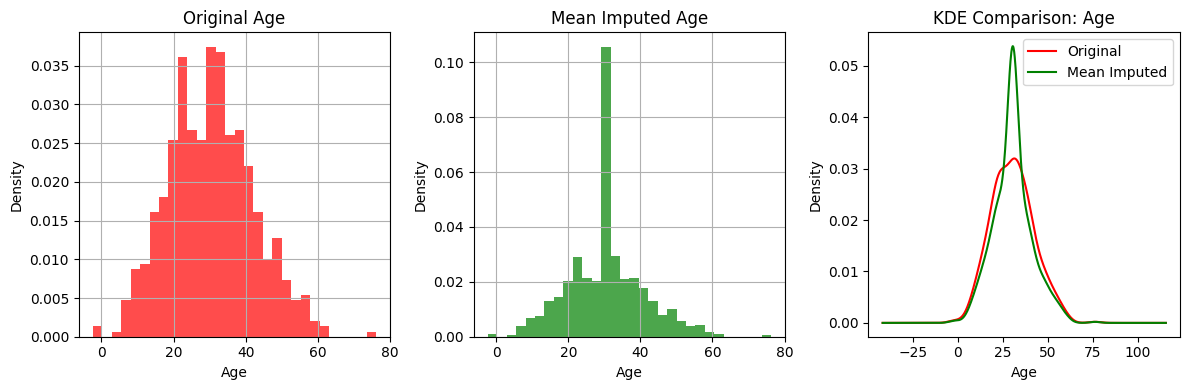

📈 IMPUTATION IMPACT ANALYSIS: Fare
📊 Variance Analysis:
   Original variance: 1162.0629
   Imputed variance: 1160.5638
   Change: -0.13%

📊 Distribution Analysis:
   Original mean: 32.61
   Imputed mean: 32.59
   Original median: 22.79
   Imputed median: 22.79


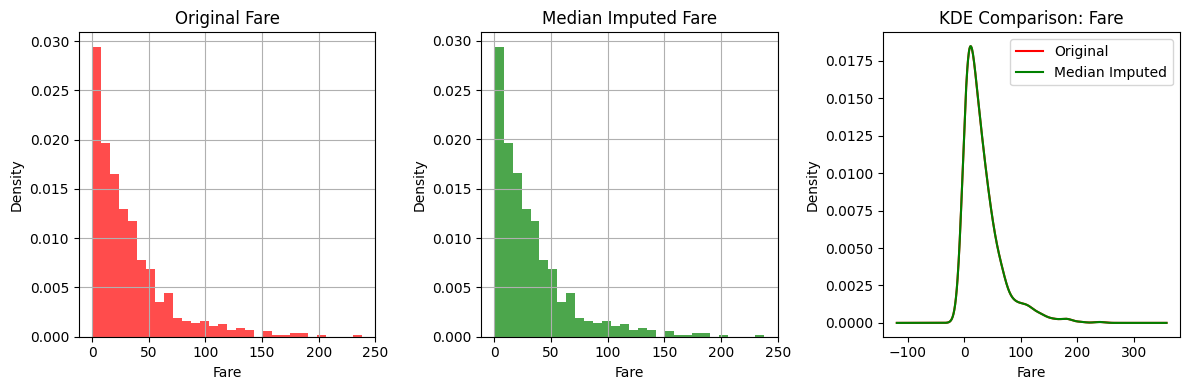

In [5]:
# 5. 📊 Variance and Distribution Analysis

def analyze_imputation_impact(original_data, imputed_data, feature_name, imputation_type):
    """
    Comprehensive analysis of imputation impact
    """

    print(f"📈 IMPUTATION IMPACT ANALYSIS: {feature_name}")
    print("=" * 60)

    # Variance analysis
    original_var = original_data.var()
    imputed_var = imputed_data.var()
    variance_change = ((imputed_var - original_var) / original_var) * 100

    print(f"📊 Variance Analysis:")
    print(f"   Original variance: {original_var:.4f}")
    print(f"   Imputed variance: {imputed_var:.4f}")
    print(f"   Change: {variance_change:+.2f}%")

    # Distribution analysis
    print(f"\n📊 Distribution Analysis:")
    print(f"   Original mean: {original_data.mean():.2f}")
    print(f"   Imputed mean: {imputed_data.mean():.2f}")
    print(f"   Original median: {original_data.median():.2f}")
    print(f"   Imputed median: {imputed_data.median():.2f}")

    # Visualization
    plt.figure(figsize=(12, 4))

    plt.subplot(131)
    original_data.hist(bins=30, alpha=0.7, color='red', density=True)
    plt.title(f'Original {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Density')

    plt.subplot(132)
    imputed_data.hist(bins=30, alpha=0.7, color='green', density=True)
    plt.title(f'{imputation_type} Imputed {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Density')

    plt.subplot(133)
    original_data.plot(kind='kde', color='red', label='Original')
    imputed_data.plot(kind='kde', color='green',
                      label=f'{imputation_type} Imputed')
    plt.title(f'KDE Comparison: {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        'original_variance': original_var,
        'imputed_variance': imputed_var,
        'variance_change_percent': variance_change
    }


# Analyze Age imputation (if exists)
if 'Age' in X_train.columns and X_train['Age'].isnull().any():

    # Determine which imputation was applied
    age_strategy = stat_imputer.statistics_.get(
        'Age', {}).get('strategy', 'median')
    age_imputed_col = f'Age_{age_strategy}'

    if age_imputed_col in X_train_imputed.columns:
        age_analysis = analyze_imputation_impact(
            X_train['Age'].dropna(),
            X_train_imputed[age_imputed_col],
            'Age',
            age_strategy.title()
        )

# Analyze Fare imputation (if exists)
if 'Fare' in X_train.columns and X_train['Fare'].isnull().any():

    fare_strategy = stat_imputer.statistics_.get(
        'Fare', {}).get('strategy', 'median')
    fare_imputed_col = f'Fare_{fare_strategy}'

    if fare_imputed_col in X_train_imputed.columns:
        fare_analysis = analyze_imputation_impact(
            X_train['Fare'].dropna(),
            X_train_imputed[fare_imputed_col],
            'Fare',
            fare_strategy.title()
        )

In [6]:
# 6. 🎯 Method 2: Arbitrary Value Imputation

class ArbitraryImputer:
    """
    Professional Arbitrary Value Imputation Class
    """

    def __init__(self, arbitrary_values=None):
        self.arbitrary_values = arbitrary_values or {}
        self.fitted_values = {}
        self.is_fitted = False

    def suggest_arbitrary_values(self, df, columns):
        """Suggest appropriate arbitrary values based on data distribution"""

        print("💡 SUGGESTING ARBITRARY VALUES")
        print("=" * 50)

        suggestions = {}

        for col in columns:
            if col not in df.columns:
                continue

            data = df[col].dropna()

            # Calculate range and suggest values
            min_val = data.min()
            max_val = data.max()

            # Suggest values outside the normal range
            negative_suggestion = - \
                1 if min_val >= 0 else min_val - abs(min_val)
            positive_suggestion = int(max_val + max_val * 0.1) + 1

            suggestions[col] = {
                'negative': negative_suggestion,
                'positive': positive_suggestion,
                'range': (min_val, max_val)
            }

            print(f"\n{col}:")
            print(f"   Data range: [{min_val:.2f}, {max_val:.2f}]")
            print(f"   🔸 Negative flag: {negative_suggestion}")
            print(f"   🔸 Positive flag: {positive_suggestion}")

        return suggestions

    def fit_transform(self, X_train, arbitrary_values=None):
        """Apply arbitrary value imputation"""

        if arbitrary_values:
            self.arbitrary_values.update(arbitrary_values)

        numerical_cols = X_train.select_dtypes(include=[np.number]).columns
        missing_cols = [
            col for col in numerical_cols if X_train[col].isnull().any()]

        if not missing_cols:
            print("ℹ️ No missing values found in numerical columns")
            return X_train.copy()

        # Get suggestions if no arbitrary values provided
        if not self.arbitrary_values:
            suggestions = self.suggest_arbitrary_values(X_train, missing_cols)

            # Use suggested values
            for col in missing_cols:
                # Default to negative flag
                self.arbitrary_values[col] = suggestions[col]['negative']

        X_imputed = X_train.copy()

        print(f"\n🔧 APPLYING ARBITRARY VALUE IMPUTATION")
        print("=" * 50)

        for col in missing_cols:
            if col in self.arbitrary_values:
                arbitrary_val = self.arbitrary_values[col]

                # Create multiple arbitrary imputations for comparison
                X_imputed[f'{col}_arb_neg'] = X_train[col].fillna(-1)
                X_imputed[f'{col}_arb_pos'] = X_train[col].fillna(
                    arbitrary_val)
                X_imputed[f'{col}_arb_99'] = X_train[col].fillna(99)
                X_imputed[f'{col}_arb_999'] = X_train[col].fillna(999)

                self.fitted_values[col] = {
                    'negative': -1,
                    'positive': arbitrary_val,
                    'standard1': 99,
                    'standard2': 999
                }

                print(f"✅ {col}: Created 4 arbitrary imputations")
                print(f"   Negative flag: -1")
                print(f"   Positive flag: {arbitrary_val}")
                print(f"   Standard flags: 99, 999")

        self.is_fitted = True
        return X_imputed

    def transform(self, X_test):
        """Transform test data using fitted arbitrary values"""

        if not self.is_fitted:
            raise ValueError("Must call fit_transform first!")

        X_imputed = X_test.copy()

        for col, values in self.fitted_values.items():
            if col in X_test.columns:
                X_imputed[f'{col}_arb_neg'] = X_test[col].fillna(
                    values['negative'])
                X_imputed[f'{col}_arb_pos'] = X_test[col].fillna(
                    values['positive'])
                X_imputed[f'{col}_arb_99'] = X_test[col].fillna(
                    values['standard1'])
                X_imputed[f'{col}_arb_999'] = X_test[col].fillna(
                    values['standard2'])

        return X_imputed


# Apply arbitrary imputation
arbitrary_imputer = ArbitraryImputer()
X_train_arbitrary = arbitrary_imputer.fit_transform(X_train)
X_test_arbitrary = arbitrary_imputer.transform(X_test)

print(f"\n📋 Arbitrary imputed columns:")
arbitrary_cols = [col for col in X_train_arbitrary.columns if '_arb_' in col]
print(arbitrary_cols)

💡 SUGGESTING ARBITRARY VALUES

Age:
   Data range: [-2.36, 76.23]
   🔸 Negative flag: -4.725279430597723
   🔸 Positive flag: 84

Fare:
   Data range: [0.10, 238.14]
   🔸 Negative flag: -1
   🔸 Positive flag: 262

🔧 APPLYING ARBITRARY VALUE IMPUTATION
✅ Age: Created 4 arbitrary imputations
   Negative flag: -1
   Positive flag: -4.725279430597723
   Standard flags: 99, 999
✅ Fare: Created 4 arbitrary imputations
   Negative flag: -1
   Positive flag: -1
   Standard flags: 99, 999

📋 Arbitrary imputed columns:
['Age_arb_neg', 'Age_arb_pos', 'Age_arb_99', 'Age_arb_999', 'Fare_arb_neg', 'Fare_arb_pos', 'Fare_arb_99', 'Fare_arb_999']


In [7]:
# 7. 🔚 Method 3: End of Distribution Imputation

class EndDistributionImputer:
    """
    Professional End of Distribution Imputation Class
    """

    def __init__(self, tail='upper', multiplier=1.5):
        self.tail = tail  # 'upper', 'lower', or 'both'
        self.multiplier = multiplier
        self.end_values = {}
        self.is_fitted = False

    def calculate_end_values(self, df, columns):
        """Calculate end of distribution values"""

        print(f"📊 CALCULATING END DISTRIBUTION VALUES")
        print("=" * 50)

        end_values = {}

        for col in columns:
            if col not in df.columns:
                continue

            data = df[col].dropna()

            # Calculate percentiles and IQR
            q1 = data.quantile(0.25)
            q3 = data.quantile(0.75)
            iqr = q3 - q1

            # Calculate boundaries
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            # End values
            min_val = data.min()
            max_val = data.max()

            # Calculate end distribution values
            upper_end = max_val + (max_val - min_val) * 0.1
            lower_end = min_val - (max_val - min_val) * 0.1

            # Alternative calculations
            percentile_99 = data.quantile(0.99)
            percentile_01 = data.quantile(0.01)

            end_values[col] = {
                'upper_end': upper_end,
                'lower_end': lower_end,
                'max_plus_range': max_val + (max_val - min_val) * self.multiplier,
                'min_minus_range': min_val - (max_val - min_val) * self.multiplier,
                'percentile_99_plus': percentile_99 + (percentile_99 * 0.1),
                'percentile_01_minus': percentile_01 - (percentile_01 * 0.1),
                'range': (min_val, max_val),
                'iqr_bounds': (lower_bound, upper_bound)
            }

            print(f"\n{col}:")
            print(f"   Data range: [{min_val:.2f}, {max_val:.2f}]")
            print(f"   IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print(f"   🔸 Upper end: {upper_end:.2f}")
            print(f"   🔸 Lower end: {lower_end:.2f}")
            print(f"   🔸 Max + range: {end_values[col]['max_plus_range']:.2f}")
            print(
                f"   🔸 99th percentile+: {end_values[col]['percentile_99_plus']:.2f}")

        return end_values

    def fit_transform(self, X_train):
        """Apply end of distribution imputation"""

        numerical_cols = X_train.select_dtypes(include=[np.number]).columns
        missing_cols = [
            col for col in numerical_cols if X_train[col].isnull().any()]

        if not missing_cols:
            print("ℹ️ No missing values found in numerical columns")
            return X_train.copy()

        # Calculate end values
        self.end_values = self.calculate_end_values(X_train, missing_cols)

        X_imputed = X_train.copy()

        print(f"\n🔧 APPLYING END DISTRIBUTION IMPUTATION")
        print("=" * 50)

        for col in missing_cols:
            values = self.end_values[col]

            # Create multiple end distribution imputations
            X_imputed[f'{col}_end_upper'] = X_train[col].fillna(
                values['upper_end'])
            X_imputed[f'{col}_end_lower'] = X_train[col].fillna(
                values['lower_end'])
            X_imputed[f'{col}_end_max_plus'] = X_train[col].fillna(
                values['max_plus_range'])
            X_imputed[f'{col}_end_99th_plus'] = X_train[col].fillna(
                values['percentile_99_plus'])

            print(f"✅ {col}: Created 4 end distribution imputations")
            print(f"   Upper end: {values['upper_end']:.2f}")
            print(f"   Lower end: {values['lower_end']:.2f}")
            print(f"   Max + range: {values['max_plus_range']:.2f}")
            print(f"   99th percentile+: {values['percentile_99_plus']:.2f}")

        self.is_fitted = True
        return X_imputed

    def transform(self, X_test):
        """Transform test data using fitted end values"""

        if not self.is_fitted:
            raise ValueError("Must call fit_transform first!")

        X_imputed = X_test.copy()

        for col, values in self.end_values.items():
            if col in X_test.columns:
                X_imputed[f'{col}_end_upper'] = X_test[col].fillna(
                    values['upper_end'])
                X_imputed[f'{col}_end_lower'] = X_test[col].fillna(
                    values['lower_end'])
                X_imputed[f'{col}_end_max_plus'] = X_test[col].fillna(
                    values['max_plus_range'])
                X_imputed[f'{col}_end_99th_plus'] = X_test[col].fillna(
                    values['percentile_99_plus'])

        return X_imputed


# Apply end distribution imputation
end_imputer = EndDistributionImputer()
X_train_end = end_imputer.fit_transform(X_train)
X_test_end = end_imputer.transform(X_test)

print(f"\n📋 End distribution imputed columns:")
end_cols = [col for col in X_train_end.columns if '_end_' in col]
print(end_cols)

📊 CALCULATING END DISTRIBUTION VALUES

Age:
   Data range: [-2.36, 76.23]
   IQR bounds: [-1.63, 61.89]
   🔸 Upper end: 84.09
   🔸 Lower end: -10.22
   🔸 Max + range: 194.13
   🔸 99th percentile+: 64.07

Fare:
   Data range: [0.10, 238.14]
   IQR bounds: [-42.54, 95.11]
   🔸 Upper end: 261.94
   🔸 Lower end: -23.70
   🔸 Max + range: 595.18
   🔸 99th percentile+: 179.89

🔧 APPLYING END DISTRIBUTION IMPUTATION
✅ Age: Created 4 end distribution imputations
   Upper end: 84.09
   Lower end: -10.22
   Max + range: 194.13
   99th percentile+: 64.07
✅ Fare: Created 4 end distribution imputations
   Upper end: 261.94
   Lower end: -23.70
   Max + range: 595.18
   99th percentile+: 179.89

📋 End distribution imputed columns:
['Age_end_upper', 'Age_end_lower', 'Age_end_max_plus', 'Age_end_99th_plus', 'Fare_end_upper', 'Fare_end_lower', 'Fare_end_max_plus', 'Fare_end_99th_plus']


In [12]:
def create_professional_imputation_pipeline():
    """
    Create production-ready imputation pipeline using sklearn
    """

    print("🔧 CREATING PROFESSIONAL SKLEARN PIPELINE")
    print("=" * 50)

    from sklearn.preprocessing import OneHotEncoder

    # Analyze X_train columns
    numerical_cols = X_train.select_dtypes(
        include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(
        include=['object', 'category']).columns.tolist()

    print(f"📊 Detected columns:")
    print(f"   Numerical: {numerical_cols}")
    print(f"   Categorical: {categorical_cols}")

    # Create transformers
    transformers = []

    # Handle numerical columns with missing values
    numerical_missing = [
        col for col in numerical_cols if X_train[col].isnull().any()]
    numerical_complete = [
        col for col in numerical_cols if not X_train[col].isnull().any()]

    for col in numerical_missing:
        if col == 'Age':
            transformers.append(
                (f'{col}_imputer', SimpleImputer(strategy='median'), [col]))
            print(f"✅ {col}: Median imputation")
        elif col == 'Fare':
            skewness = X_train[col].dropna().skew()
            strategy = 'mean' if abs(skewness) < 0.5 else 'median'
            transformers.append(
                (f'{col}_imputer', SimpleImputer(strategy=strategy), [col]))
            print(
                f"✅ {col}: {strategy.title()} imputation (skewness: {skewness:.2f})")
        else:
            transformers.append(
                (f'{col}_imputer', SimpleImputer(strategy='median'), [col]))
            print(f"✅ {col}: Median imputation")

    # Handle complete numerical columns
    if numerical_complete:
        transformers.append(
            ('numerical_passthrough', 'passthrough', numerical_complete))
        print(f"✅ Complete numerical: Passthrough ({numerical_complete})")

    # Handle categorical columns
    if categorical_cols:
        cat_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ])
        transformers.append(('categorical', cat_transformer, categorical_cols))
        print(f"✅ Categorical: Impute + OneHot encode ({categorical_cols})")

    # Create pipeline
    if transformers:
        preprocessor = ColumnTransformer(
            transformers=transformers,
            remainder='drop'
        )

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(
                random_state=42, n_estimators=100))
        ])

        print(f"✅ Created pipeline with {len(transformers)} transformers")
        return pipeline
    else:
        print("⚠️ No transformers needed - no missing values")
        return None


# Test the fixed pipeline
professional_pipeline = create_professional_imputation_pipeline()

if professional_pipeline:
    # This should work now!
    professional_pipeline.fit(X_train, y_train)
    score = professional_pipeline.score(X_test, y_test)
    print(f"\n📊 Pipeline test score: {score:.4f}")

    # Get predictions
    y_pred = professional_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n🎯 MODEL PERFORMANCE:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Correct predictions: {sum(y_pred == y_test)}/{len(y_test)}")

🔧 CREATING PROFESSIONAL SKLEARN PIPELINE
📊 Detected columns:
   Numerical: ['Age', 'Fare', 'Family', 'IsAlone']
   Categorical: ['FamilySize_Category']
✅ Age: Median imputation
✅ Fare: Median imputation (skewness: 2.09)
✅ Complete numerical: Passthrough (['Family', 'IsAlone'])
✅ Categorical: Impute + OneHot encode (['FamilySize_Category'])
✅ Created pipeline with 4 transformers

📊 Pipeline test score: 0.5196

🎯 MODEL PERFORMANCE:
   Accuracy: 0.5196
   Correct predictions: 93/179


🏆 COMPREHENSIVE IMPUTATION METHOD COMPARISON
📊 DISTRIBUTION ANALYSIS FOR IMPUTATION STRATEGY

Age:
   Mean: 30.48
   Median: 30.31
   Skewness: 0.25
   📋 Recommendation: Use mean (Normal distribution (low skewness))

Fare:
   Mean: 32.61
   Median: 22.79
   Skewness: 2.09
   📋 Recommendation: Use median (Skewed distribution (skewness: 2.09))

🔧 APPLYING STATISTICAL IMPUTATION
✅ Age: Filled with mean = 30.48
✅ Fare: Filled with median = 22.79
✅ Statistical Imputation: 0.5140
❌ Arbitrary Value failed: could not convert string to float: 'Small'
❌ End Distribution failed: could not convert string to float: 'Small'
❌ Professional Pipeline failed: could not convert string to float: 'Small'


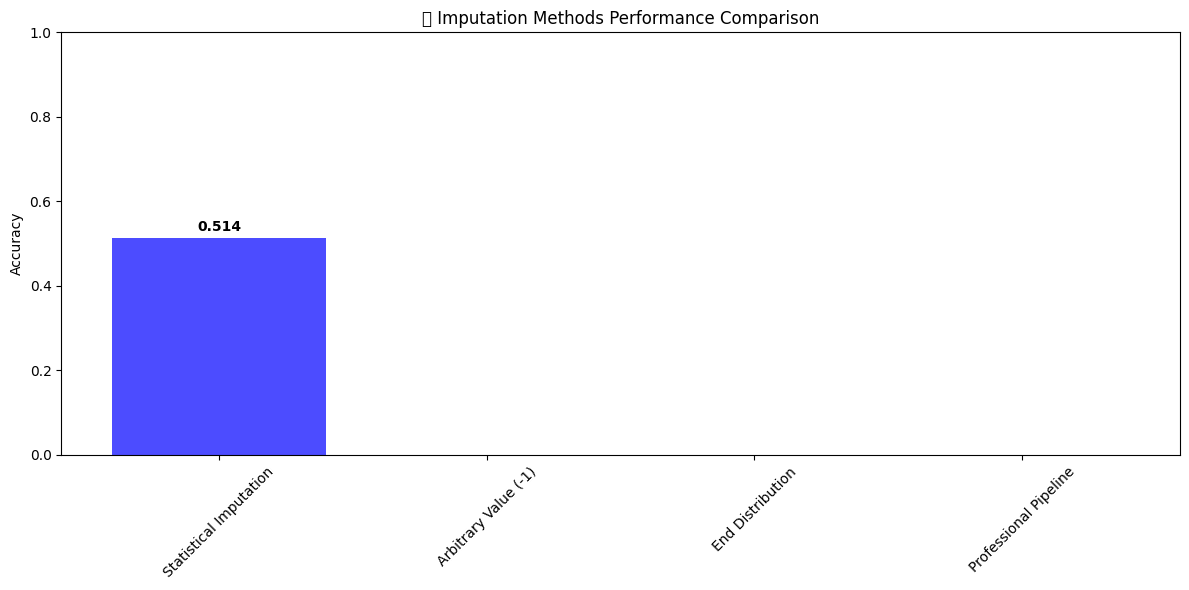


🏆 Best performing method: Statistical Imputation
   Accuracy: 0.5140


In [10]:
# 9. 📊 Compare All Imputation Methods

def compare_imputation_methods(X_train, X_test, y_train, y_test):
    """
    Comprehensive comparison of all imputation methods
    """

    print("🏆 COMPREHENSIVE IMPUTATION METHOD COMPARISON")
    print("=" * 60)

    results = {}

    # Method 1: Statistical Imputation (our enhanced method)
    try:
        stat_imputer = StatisticalImputer()
        X_train_stat = stat_imputer.fit_transform(X_train)
        X_test_stat = stat_imputer.transform(X_test)

        # Use only the imputed columns for fair comparison
        imputed_cols = [
            col for col in X_train_stat.columns if '_mean' in col or '_median' in col]
        other_cols = [
            'Family', 'IsAlone'] if 'Family' in X_train_stat.columns else []
        feature_cols = imputed_cols + other_cols

        if feature_cols:
            model = RandomForestClassifier(random_state=42)
            model.fit(X_train_stat[feature_cols], y_train)
            accuracy = accuracy_score(
                y_test, model.predict(X_test_stat[feature_cols]))
            results['Statistical Imputation'] = accuracy
            print(f"✅ Statistical Imputation: {accuracy:.4f}")
    except Exception as e:
        print(f"❌ Statistical Imputation failed: {e}")
        results['Statistical Imputation'] = 0

    # Method 2: Arbitrary Value (-1)
    try:
        X_train_arb = X_train.copy()
        X_test_arb = X_test.copy()

        # Simple arbitrary imputation
        for col in X_train.select_dtypes(include=[np.number]).columns:
            if X_train[col].isnull().any():
                X_train_arb[col] = X_train[col].fillna(-1)
                X_test_arb[col] = X_test[col].fillna(-1)

        model = RandomForestClassifier(random_state=42)
        model.fit(X_train_arb, y_train)
        accuracy = accuracy_score(y_test, model.predict(X_test_arb))
        results['Arbitrary Value (-1)'] = accuracy
        print(f"✅ Arbitrary Value (-1): {accuracy:.4f}")
    except Exception as e:
        print(f"❌ Arbitrary Value failed: {e}")
        results['Arbitrary Value (-1)'] = 0

    # Method 3: End Distribution
    try:
        X_train_end = X_train.copy()
        X_test_end = X_test.copy()

        # Simple end distribution imputation
        for col in X_train.select_dtypes(include=[np.number]).columns:
            if X_train[col].isnull().any():
                max_val = X_train[col].max()
                end_val = max_val + (max_val * 0.1)
                X_train_end[col] = X_train[col].fillna(end_val)
                X_test_end[col] = X_test[col].fillna(end_val)

        model = RandomForestClassifier(random_state=42)
        model.fit(X_train_end, y_train)
        accuracy = accuracy_score(y_test, model.predict(X_test_end))
        results['End Distribution'] = accuracy
        print(f"✅ End Distribution: {accuracy:.4f}")
    except Exception as e:
        print(f"❌ End Distribution failed: {e}")
        results['End Distribution'] = 0

    # Method 4: Professional Pipeline (sklearn)
    try:
        if professional_pipeline:
            professional_pipeline.fit(X_train, y_train)
            accuracy = accuracy_score(
                y_test, professional_pipeline.predict(X_test))
            results['Professional Pipeline'] = accuracy
            print(f"✅ Professional Pipeline: {accuracy:.4f}")
    except Exception as e:
        print(f"❌ Professional Pipeline failed: {e}")
        results['Professional Pipeline'] = 0

    return results


# Compare all methods
comparison_results = compare_imputation_methods(
    X_train, X_test, y_train, y_test)

# Visualize comparison
if comparison_results:
    plt.figure(figsize=(12, 6))
    methods = list(comparison_results.keys())
    scores = list(comparison_results.values())
    colors = ['blue', 'orange', 'green', 'red'][:len(methods)]

    bars = plt.bar(methods, scores, color=colors, alpha=0.7)
    plt.title('🏆 Imputation Methods Performance Comparison')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)

    # Add value labels
    for bar, score in zip(bars, scores):
        if score > 0:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Best method
    if any(score > 0 for score in scores):
        best_method = max(comparison_results, key=comparison_results.get)
        print(f"\n🏆 Best performing method: {best_method}")
        print(f"   Accuracy: {comparison_results[best_method]:.4f}")

In [11]:
# 10. 📋 Professional Template

# Copy this for your projects:

# 📊 PROFESSIONAL TEMPLATE - COPY FOR YOUR PROJECTS!

class UniversalImputer:
    """
    Universal imputation class for any dataset
    """

    def __init__(self):
        self.strategies = {}
        self.imputers = {}
        self.is_fitted = False

    def auto_detect_strategy(self, df, missing_threshold=0.05):
        """
        Automatically detect best imputation strategy for each column
        
        Parameters:
        df: pandas DataFrame
        missing_threshold: float, threshold for missing percentage
        
        Returns:
        dict: recommended strategies for each column
        """

        strategies = {}

        for col in df.columns:
            missing_pct = df[col].isnull().mean()

            if missing_pct == 0:
                strategies[col] = 'no_imputation'
            elif missing_pct > missing_threshold:
                strategies[col] = 'arbitrary'  # High missing rate
            elif df[col].dtype in ['int64', 'float64']:
                # Numerical column
                skewness = df[col].dropna().skew()
                if abs(skewness) < 0.5:
                    strategies[col] = 'mean'
                else:
                    strategies[col] = 'median'
            else:
                # Categorical column
                strategies[col] = 'mode'

        return strategies

    def create_imputation_pipeline(self, X, target_col=None, custom_strategies=None):
        """
        Create comprehensive imputation pipeline
        
        Parameters:
        X: pandas DataFrame
        target_col: str, target column name (to exclude from imputation)
        custom_strategies: dict, custom strategies for specific columns
        
        Returns:
        sklearn ColumnTransformer
        """

        if target_col and target_col in X.columns:
            X_features = X.drop(columns=[target_col])
        else:
            X_features = X.copy()

        # Auto-detect strategies
        auto_strategies = self.auto_detect_strategy(X_features)

        # Apply custom strategies if provided
        if custom_strategies:
            auto_strategies.update(custom_strategies)

        self.strategies = auto_strategies

        # Group columns by strategy
        strategy_groups = {}
        for col, strategy in auto_strategies.items():
            if strategy not in strategy_groups:
                strategy_groups[strategy] = []
            strategy_groups[strategy].append(col)

        # Create transformers
        transformers = []

        for strategy, columns in strategy_groups.items():
            if strategy == 'no_imputation':
                transformers.append((strategy, 'passthrough', columns))
            elif strategy == 'mean':
                transformers.append(
                    (strategy, SimpleImputer(strategy='mean'), columns))
            elif strategy == 'median':
                transformers.append(
                    (strategy, SimpleImputer(strategy='median'), columns))
            elif strategy == 'mode':
                transformers.append(
                    (strategy, SimpleImputer(strategy='most_frequent'), columns))
            elif strategy == 'arbitrary':
                transformers.append((strategy, SimpleImputer(
                    strategy='constant', fill_value=-1), columns))

        # Create ColumnTransformer
        imputer = ColumnTransformer(
            transformers=transformers,
            remainder='drop'
        )

        self.imputers = imputer
        return imputer

    def fit_transform(self, X, y=None, target_col=None):
        """Fit and transform data"""

        imputer = self.create_imputation_pipeline(X, target_col)
        X_imputed = imputer.fit_transform(X)
        self.is_fitted = True

        return X_imputed

    def transform(self, X):
        """Transform new data"""

        if not self.is_fitted:
            raise ValueError("Must call fit_transform first!")

        return self.imputers.transform(X)

    def get_strategies(self):
        """Get applied strategies"""
        return self.strategies


# Example usage template
print("📊 Universal Imputer Created!")
print("\n📝 Usage Examples:")
print("   # Initialize imputer")
print("   imputer = UniversalImputer()")
print("   ")
print("   # Auto-detect and apply imputation")
print("   X_imputed = imputer.fit_transform(X_train, target_col='target')")
print("   X_test_imputed = imputer.transform(X_test)")
print("   ")
print("   # Check applied strategies")
print("   strategies = imputer.get_strategies()")

# Test universal imputer
universal_imputer = UniversalImputer()
X_universal = universal_imputer.fit_transform(X_train, target_col='Survived')
strategies_applied = universal_imputer.get_strategies()

print(f"\n✅ Universal Imputer tested!")
print(f"   Applied strategies: {strategies_applied}")
print(f"   Imputed shape: {X_universal.shape}")

📊 Universal Imputer Created!

📝 Usage Examples:
   # Initialize imputer
   imputer = UniversalImputer()
   
   # Auto-detect and apply imputation
   X_imputed = imputer.fit_transform(X_train, target_col='target')
   X_test_imputed = imputer.transform(X_test)
   
   # Check applied strategies
   strategies = imputer.get_strategies()

✅ Universal Imputer tested!
   Applied strategies: {'Age': 'arbitrary', 'Fare': 'median', 'Family': 'no_imputation', 'IsAlone': 'no_imputation', 'FamilySize_Category': 'no_imputation'}
   Imputed shape: (712, 5)
